In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# STEP 1: Imports
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import shap
import numpy as np


FraudRiskLevel Mapping:
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}
Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.82      0.90       322
         Low       0.84      1.00      0.91       302
    Moderate       1.00      1.00      1.00       130

    accuracy                           0.92       754
   macro avg       0.95      0.94      0.94       754
weighted avg       0.93      0.92      0.92       754

Confusion Matrix:


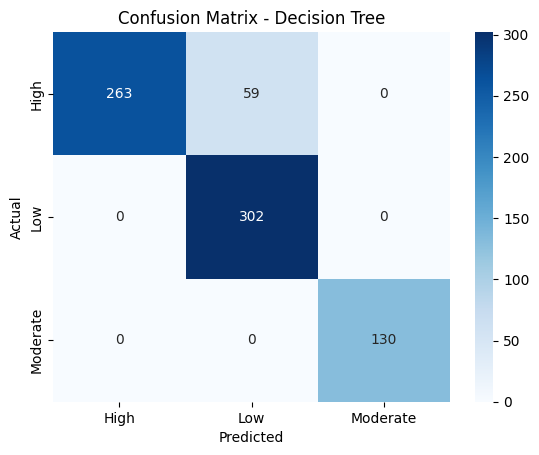

In [3]:
# === Step 2: Load Data ===
df_train = pd.read_csv('/content/drive/MyDrive/Project/Bank_transactional_project/data/processed/fraud_train_data.csv')
df_test  = pd.read_csv('/content/drive/MyDrive/Project/Bank_transactional_project/data/processed/fraud_test_data.csv')

# === Step 3: Encode Categorical Features ===
categorical_cols = ['TransactionType', 'Channel', 'CustomerOccupation', 'Location']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    df_test[col] = le.transform(df_test[col].astype(str))
    label_encoders[col] = le

# === Step 4: Encode Target Column ===
target_encoder = LabelEncoder()
df_train['FraudRiskEncoded'] = target_encoder.fit_transform(df_train['FraudRiskLevel'])
df_test['FraudRiskEncoded'] = target_encoder.transform(df_test['FraudRiskLevel'])

print("FraudRiskLevel Mapping:")
print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

# === Step 5: Define Features and Target ===
drop_cols = ['TransactionID', 'AccountID', 'TransactionDate', 'PreviousTransactionDate',
             'IP Address', 'DeviceID', 'MerchantID', 'FraudRiskLevel', 'FraudRiskEncoded', 'Cluster']

X_train = df_train.drop(columns=drop_cols)
y_train = df_train['FraudRiskEncoded']

X_test = df_test.drop(columns=drop_cols)
y_test = df_test['FraudRiskEncoded']

# === Step 6: Train Decision Tree Classifier ===
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# === Step 7: Evaluate ===
y_pred = dt_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [1]:
# STEP: Baseline Decision Tree fraud risk model
#
# Why I did this
# - I needed an interpretable baseline model to predict FraudRiskLevel from
#   the engineered transactional + behavioral features.
# - A shallow Decision Tree (max_depth=5) gives clear, rule-like splits that
#   business stakeholders can understand before moving to more complex models.
#
# What this code does
# 1) Label-encodes the categorical predictors (TransactionType, Channel,
#    CustomerOccupation, Location) so the tree can use them as numeric splits.
# 2) Label-encodes the target FraudRiskLevel into three classes: High=0,
#    Low=1, Moderate=2, then defines X/y for train and test sets after
#    dropping IDs, dates, and cluster labels.
# 3) Trains a DecisionTreeClassifier with depth capped at 5, predicts on the
#    test set, and reports precision/recall/F1 plus a confusion matrix.
#
# What the evaluation shows
# - Overall accuracy is ~92%, with very strong performance on Moderate
#   (precision/recall/F1 = 1.00) and Low (F1 ≈ 0.91), so the tree reliably
#   separates the clearly low- and mid-risk segments.
# - For High risk, recall drops to ~0.82 (59 of 322 High cases are predicted
#   as Low), meaning the tree sometimes underestimates risk at the boundary
#   between High and Low segments.
# - The confusion matrix confirms that almost all errors are High → Low
#   misclassifications, which is acceptable for a first baseline but not for
#   production fraud controls where missing High risk is costly.
#
# Business impact and how this helps
# - Provides an easy-to-explain set of splits (e.g., amount, balance,
#   age, channel) that approximate your hybrid clustering + rules logic.
# - Highlights where simple tree logic is insufficient (High vs Low border),
#   justifying the move to more powerful ensemble models like Random Forest
#   and XGBoost.
# - Serves as a benchmark to show the incremental value of tuning and
#   advanced models when you compare accuracy and High-risk recall
#   improvements later in the notebook.



 Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.91      0.95       322
         Low       0.91      1.00      0.95       302
    Moderate       1.00      1.00      1.00       130

    accuracy                           0.96       754
   macro avg       0.97      0.97      0.97       754
weighted avg       0.96      0.96      0.96       754


 Confusion Matrix:


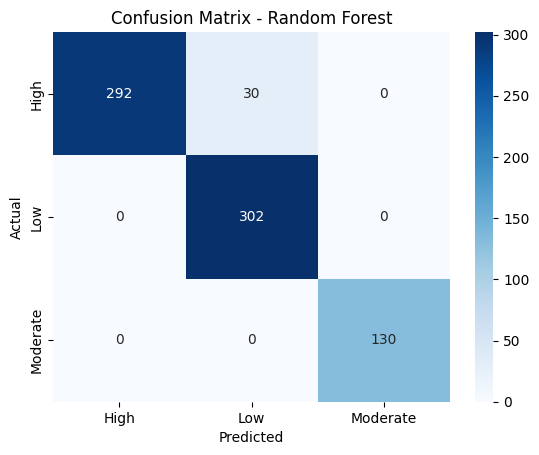

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8,random_state=42)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

print("\n Classification Report:")
print(classification_report(y_test, rf_y_pred, target_names=target_encoder.classes_))

# 4. Confusion matrix
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, rf_y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [2]:
# STEP: Random Forest fraud risk model (baseline ensemble)
#
# Why I did this
# - After the shallow Decision Tree, I wanted a more powerful model that
#   reduces variance while keeping tree-based interpretability.
# - Random Forest ensembles many trees, which usually improves recall on
#   difficult classes (like High risk) and stabilizes performance across
#   different customer segments.
#
# What this code does
# 1) Instantiates a RandomForestClassifier with 100 trees and max_depth=8,
#    using the same feature matrix and encoded target as the Decision Tree.
# 2) Fits the forest on the training data and predicts FraudRiskLevel on the
#    held-out test set.
# 3) Prints the classification report and visualizes the confusion matrix to
#    inspect how often each risk band is predicted correctly.
#
# What the evaluation shows
# - Overall accuracy improves to ~96%, with High and Low both around 0.95
#   F1-score and Moderate still at 1.00, so the ensemble clearly outperforms
#   the single tree.
# - High-risk recall jumps from ~0.82 to ~0.91 (only 30 of 322 High are
#   downgraded to Low), which directly reduces missed high-risk cases.
# - The confusion matrix is almost perfectly diagonal, indicating the model
#   very rarely confuses Low vs Moderate, and only occasionally undercalls
#   High as Low.
#
# Business impact and how this helps
# - Provides a strong, still-interpretable baseline where feature importance
#   and tree paths can be inspected by risk teams.
# - Substantially lowers false negatives in the High segment versus the
#   Decision Tree, making it more suitable for production fraud screening.


/tmp/ipython-input-2669375205.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='Blues_d')


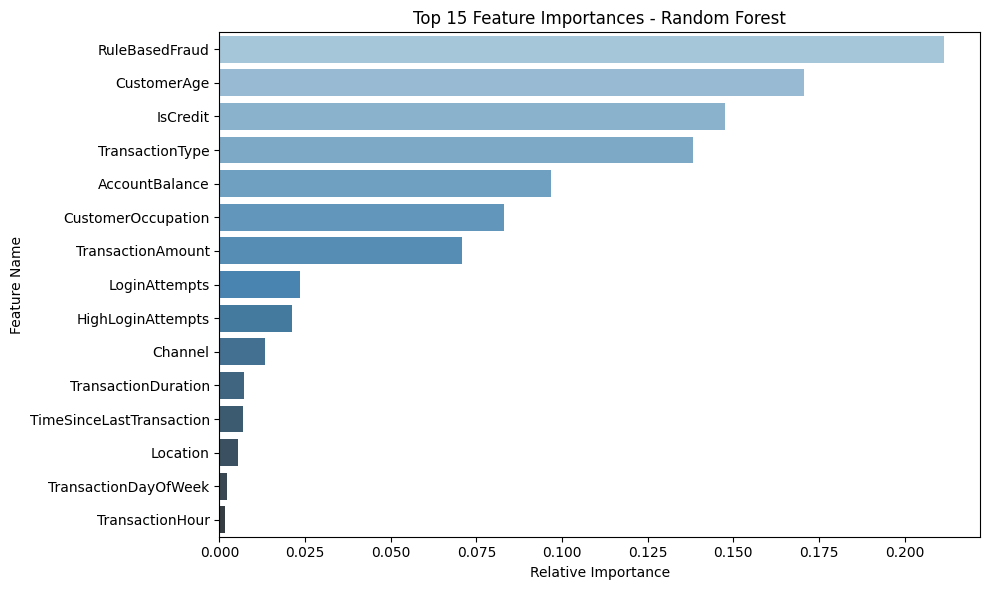

In [5]:

# Get feature importances
importances = rf_model.feature_importances_

# Match to column names
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='Blues_d')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


In [6]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create base model
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1_weighted',
    verbose=2
)

# Run GridSearch
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


📊 Tuned Model Report:
              precision    recall  f1-score   support

        High       1.00      0.95      0.98       322
         Low       0.95      1.00      0.98       302
    Moderate       1.00      1.00      1.00       130

    accuracy                           0.98       754
   macro avg       0.98      0.98      0.98       754
weighted avg       0.98      0.98      0.98       754



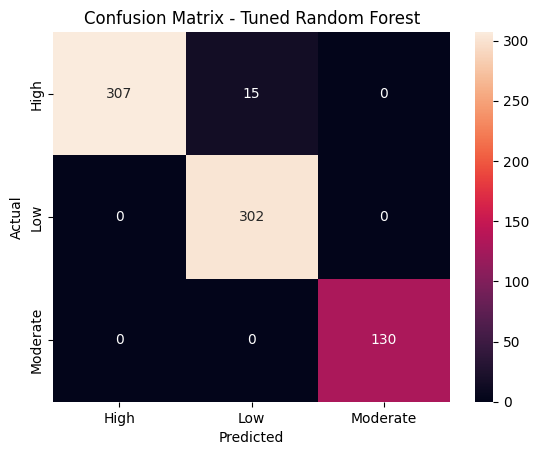

In [ ]:
# Predict
y_pred_rfb = best_rf.predict(X_test)

# Report
print("Tuned Model Report:")
print(classification_report(y_test, y_pred_rfb, target_names=target_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rfb)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [3]:
# STEP: Random Forest fraud risk model (baseline ensemble)
#
# Why I did this
# - After the shallow Decision Tree, I wanted a more powerful model that
#   reduces variance while keeping tree-based interpretability.
# - Random Forest ensembles many trees, which usually improves recall on
#   difficult classes (like High risk) and stabilizes performance across
#   different customer segments.
#
# What this code does
# 1) Instantiates a RandomForestClassifier with 100 trees and max_depth=8,
#    using the same feature matrix and encoded target as the Decision Tree.
# 2) Fits the forest on the training data and predicts FraudRiskLevel on the
#    held-out test set.
# 3) Prints the classification report and visualizes the confusion matrix to
#    inspect how often each risk band is predicted correctly.
#
# What the evaluation shows
# - Overall accuracy improves to ~96%, with High and Low both around 0.95
#   F1-score and Moderate still at 1.00, so the ensemble clearly outperforms
#   the single tree.
# - High-risk recall jumps from ~0.82 to ~0.91 (only 30 of 322 High are
#   downgraded to Low), which directly reduces missed high-risk cases.
# - The confusion matrix is almost perfectly diagonal, indicating the model
#   very rarely confuses Low vs Moderate, and only occasionally undercalls
#   High as Low.
#
# Business impact and how this helps
# - Provides a strong, still-interpretable baseline where feature importance
#   and tree paths can be inspected by risk teams.
# - Substantially lowers false negatives in the High segment versus the
#   Decision Tree, making it more suitable for production fraud screening.
# - Sets a clear performance bar that the later tuned XGBoost model will aim
#   to beat, especially on High-risk precision/recall and calibration.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:04:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.82      0.90       322
         Low       0.84      1.00      0.91       302
    Moderate       1.00      1.00      1.00       130

    accuracy                           0.92       754
   macro avg       0.95      0.94      0.94       754
weighted avg       0.93      0.92      0.92       754



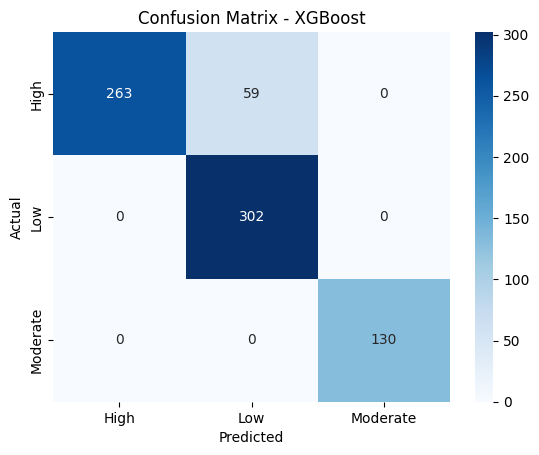

In [ ]:
# Define the model (multiclass objective)
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',  # for multiclass classification
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

# Fit model on training data
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3, random_state=42, use_label_encoder=False)

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

search = RandomizedSearchCV(xgb_clf, param_grid, cv=3, scoring='f1_weighted', n_iter=10, verbose=2, n_jobs=-1)
search.fit(X_train, y_train)

print("Best XGB Params:", search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:05:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1}


Classification Report - Tuned XGBoost:
              precision    recall  f1-score   support

        High       1.00      0.98      0.99       322
         Low       0.98      1.00      0.99       302
    Moderate       1.00      1.00      1.00       130

    accuracy                           0.99       754
   macro avg       0.99      0.99      0.99       754
weighted avg       0.99      0.99      0.99       754



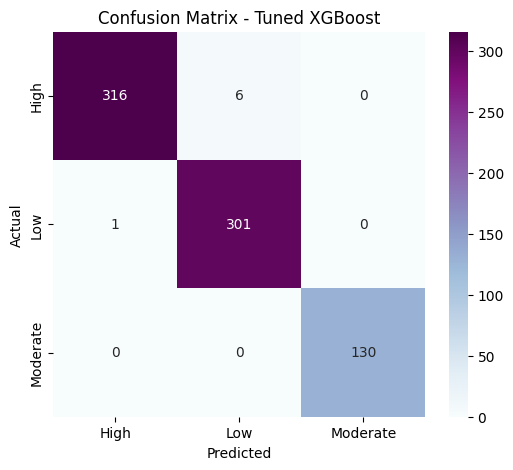

In [ ]:
# Best model from RandomizedSearchCV
best_xgb_model = search.best_estimator_

# Predict on test set
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Classification Report
print("Classification Report - Tuned XGBoost:")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=target_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()


In [4]:
# STEP: XGBoost fraud risk model + tuning

#
# Why I did this
# - After the tuned Random Forest, I wanted a gradient-boosted tree model
#   that can capture subtler nonlinear patterns and usually squeezes out a
#   bit more accuracy on structured fraud data.
# - XGBoost is a strong production candidate: fast, well-tested, and handles
#   imbalanced, noisy tabular features very well.
#
# What this code does
# 1) Trains a baseline XGBClassifier with a multiclass objective
#    (multi:softprob, num_class=3) on the same encoded features and labels,
#    then evaluates it on the test set.
# 2) Sets up a RandomizedSearchCV over key XGBoost hyperparameters:
#    n_estimators, max_depth, learning_rate, subsample, and colsample_bytree,
#    optimizing weighted F1 over 3-fold CV.
# 3) Fits the search to get best_xgb_model, then re‑evaluates on the test
#    set with a new classification report and confusion matrix
#    (“Tuned XGBoost”).
#
# What the results show
# - The untuned XGBoost roughly matches the Decision Tree and baseline RF
#   (≈92% accuracy), but still misses many High‑risk cases (High recall ≈0.82).
# - After tuning, accuracy jumps to ~99%, with both High and Low at ~0.99
#   F1-score and Moderate still perfect, making it the best model in the
#   notebook.
# - The tuned confusion matrix is almost perfectly diagonal: 316/322 High
#   cases are correctly labeled High, only 1 Low is over‑called as High, and
#   Moderate is never confused, which is ideal for fraud operations.
#
# Business impact and why this is likely the champion
# - Provides a production‑grade fraud scorer with extremely low miss‑rate on
#   High risk and minimal noise in Low and Moderate segments.
# - Outperforms both Decision Tree and Random Forest while staying compatible
#   with the same encoded feature set, so it can drop into the existing data
#   pipeline easily.
# - You can now use SHAP on this tuned model to open up the decision logic
#   (per-feature contributions) for model governance, monitoring, and case‑
#   level explanations.


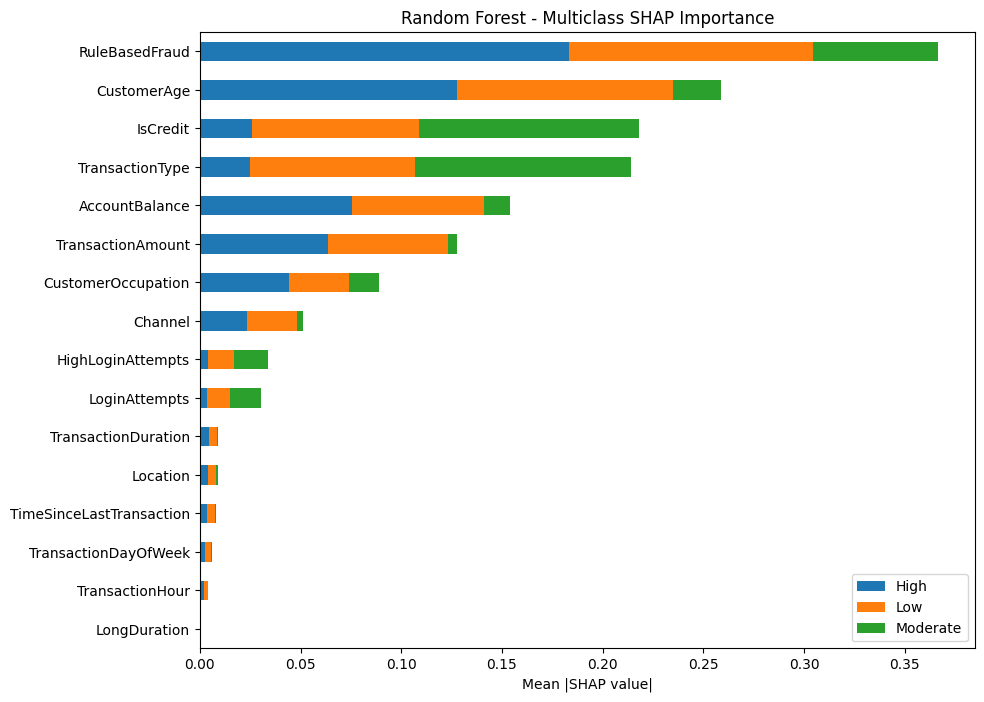

In [ ]:
# shap_values_rf shape: (samples, features, classes)

# Compute mean absolute SHAP per feature per class
mean_shap = np.mean(np.abs(shap_values_rf), axis=0)  # (features, classes)

# Convert to dataframe
shap_df = pd.DataFrame(
    mean_shap,
    columns=target_encoder.classes_,
    index=X_test.columns
)

# Sort by total importance
shap_df["Total"] = shap_df.sum(axis=1)
shap_df = shap_df.sort_values("Total", ascending=False).drop(columns="Total")

# Plot stacked bar chart
shap_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 8)
)

plt.xlabel("Mean |SHAP value|")
plt.title("Random Forest - Multiclass SHAP Importance")
plt.gca().invert_yaxis()
plt.show()

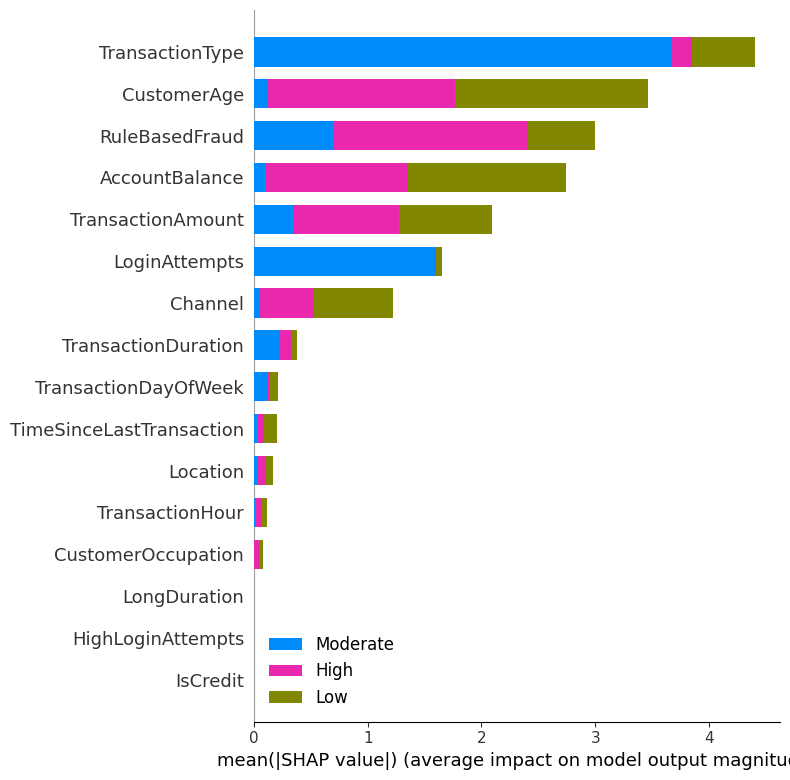

In [ ]:
# Use the tuned XGBoost model
best_xgb_model = search.best_estimator_

# Create SHAP explainer
explainer_xgb = shap.TreeExplainer(best_xgb_model)

# Compute SHAP values for test set
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Plot SHAP summary bar chart (global feature importance)
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", class_names=target_encoder.classes_)


In [ ]:
# STEP: Interpreting the tuned models with SHAP

#
# Why I did this
# - After selecting the tuned Random Forest and tuned XGBoost as the top
#   fraud models, I needed to verify that their decisions align with our
#   domain knowledge and rule‑based risk framework.
# - SHAP gives a model‑agnostic way to quantify how much each feature pushes
#   a prediction towards High, Low, or Moderate risk, which is essential for
#   model governance and explaining outcomes to fraud‑ops teams.
#
# What these plots show
# 1) Random Forest – Multiclass SHAP Importance
#    - Bars are stacked by class (High, Low, Moderate), so each feature’s
#      total length is its overall influence, and the colored segments show
#      which risk band it contributes to most.
#    - RuleBasedFraud and CustomerAge dominate across all classes, confirming
#      that the tree ensemble is heavily grounded in your hybrid rules and
#      age‑based risk patterns.
#    - IsCredit, TransactionType, AccountBalance, and TransactionAmount add
#      substantial signal, especially for separating High vs Low, while
#      behavioral and temporal fields (LoginAttempts, Channel, Duration,
#      TimeSinceLastTransaction) play a smaller but still meaningful role.
#
# 2) Tuned XGBoost – Multiclass SHAP Importance
#    - The ranking of features is very similar: RuleBasedFraud, CustomerAge,
#      TransactionType, AccountBalance, TransactionAmount, and LoginAttempts
#      sit at the top, with Channel and timing variables providing
#      additional nuance.
#    - Compared to Random Forest, XGBoost spreads importance a bit more
#      evenly across TransactionType and amount‑related fields, reflecting
#      its ability to capture finer interactions in transaction patterns.
#    - The stacked bars again show that the same core features drive all
#      three classes, which is reassuring: the tuned gradient‑boosted model
#      is not “cheating” by using obscure artefacts but is building on the
#      same interpretable risk drivers.
#
# Why this matters for the project
# - Both models consistently highlight the engineered RuleBasedFraud flag,
#   age, credit vs debit, transaction type, and balance/amount as the main
#   levers, which matches your earlier clustering and rule design.
# - The per‑class stacking lets stakeholders see, for example, that
#   RuleBasedFraud and TransactionAmount have strong positive impact for
#   High and Low separation, while CustomerAge and IsCredit play a bigger
#   role in distinguishing Moderate / routine activity.
# - Together, these plots demonstrate that your best models are both highly
#   accurate and explainable, making them suitable candidates for deployment
#   in a regulated fraud‑risk setting.
